In [11]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import connected_components
import os

import pickle
from joblib import Parallel, delayed

# knn graph, find unique edges

In [2]:
k = 5

In [19]:
filtered_points = pd.read_csv(r'..\results\202602051550_msg2-815IO_VMSC11512_region_R5-7223_annotated_filtered.csv')

In [20]:
adj_matrix = kneighbors_graph(filtered_points[['center_x', 'center_y']], n_neighbors=k, mode='connectivity', include_self=False)

adj_matrix = adj_matrix.maximum(adj_matrix.T)

row, col = adj_matrix.nonzero()
edges = np.column_stack([row, col])
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [21]:
with open(r'..\results\stromal_neighborhoods\r5_7223_filterededges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

# sample 2-hop neighbors

In [4]:
def one_hop_neighbors(cell, cell_metadata, edges):
    idx = cell_metadata.index.get_loc(cell)
    neighbors = set()
    for edge in edges:
        if edge[0] == idx:
            neighbors.add(edge[1])
        elif edge[1] == idx:
            neighbors.add(edge[0])
    # neighbor_cells = []
    # for items in neighbors:
    #     neighbor_cells.append(cell_metadata.index[items])
    return list(neighbors)

def two_hop_neighbors(cell, cell_metadata, edges):
    one_hop = one_hop_neighbors(cell, cell_metadata, edges)
    two_hop = set()

    for neighbor in one_hop:
        two_hop.update(one_hop_neighbors(neighbor, cell_metadata, edges))
    
    two_hop.update(one_hop)
    # two_hop.discard(cell_metadata.index.get_loc(cell))
    return list(two_hop)

def edges_in_subgraph(neighborhood, edges):
    neighborhood = set(neighborhood)
    subgraph_edges = []
    for edge in edges:
        if edge[0] in neighborhood and edge[1] in neighborhood:
            subgraph_edges.append(edge)
    return subgraph_edges

In [5]:
from collections import defaultdict, deque

def build_adjacency_list(edges, num_nodes):
    adj = defaultdict(set)
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)
    return adj

def k_hop_neighbors(cell, cell_metadata, edges, k):
    idx = cell_metadata.index.get_loc(cell)
    num_nodes = len(cell_metadata)
    adj = build_adjacency_list(edges, num_nodes)

    visited = set([idx])
    queue = deque([(idx, 0)])
    
    while queue:
        current, depth = queue.popleft()
        if depth >= k:
            continue
        for neighbor in adj[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))

    return list(visited)


In [6]:
# Processing function
def sub_graphs(cell, cell_metadata, edges):
    two_hop = k_hop_neighbors(cell, cell_metadata, edges, 2)

    two_hop_edges = edges_in_subgraph(two_hop, edges)
    two_hop_edges_by_id = []
    for item in two_hop_edges:
        two_hop_edges_by_id.append((cell_metadata.iloc[item[0]]['cell'], cell_metadata.iloc[item[1]]['cell']))

    return two_hop_edges_by_id

In [7]:
neighborhood_dir = r'..\results\stromal_neighborhoods'

## R1-7263

In [8]:
filtered_points = pd.read_csv(r'..\results\202602051550_msg2-815IO_VMSC11512_region_R1-7263_annotated_filtered.csv')
unique_edges = pd.read_pickle(r'..\results\stromal_neighborhoods\r1_7263_filterededges.pkl')

In [13]:
exp_df = pd.read_csv(r'Y:\coskun-lab3\Zhou\12_MSG\MERSCOPE\202602051550_msg2-815IO_VMSC11512\region_R1-7263\cell_by_gene.csv')

In [14]:
exp_df

,cell,PDK4,CCL26,DVL2,CX3CL1,PGLYRP1,CD4,ERCC1,SNAI2,TNFRSF17,...,Blank-75,Blank-76,Blank-77,Blank-78,Blank-79,Blank-80,Blank-81,Blank-82,Blank-83,Blank-84
0,1381558700001100041,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1381558700001100046,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1381558700001100048,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1381558700001100049,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1381558700001100051,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26311,1381558700044100111,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26312,1381558700044100115,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26313,1381558700044100116,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26314,1381558700044100117,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
filtered_points

,cell,volume,center_x,center_y,n_counts,n_genes,leiden,cell_type
0,1381558700001100041,1244.177621,1042.379424,-822.576048,20,19,17,Stromal
1,1381558700001100046,935.224155,1048.295402,-837.055140,116,78,2,Stromal
2,1381558700001100048,2687.832009,1019.025717,-846.911174,300,137,2,Stromal
3,1381558700001100049,834.602354,1047.925600,-850.446140,71,54,17,Stromal
4,1381558700001100051,1201.937941,1036.872597,-864.385508,131,91,17,Stromal
...,...,...,...,...,...,...,...,...
25782,1381558700044100108,2342.231138,1242.486695,-3350.617630,981,206,5,Acini
25783,1381558700044100110,423.353351,1286.325471,-3345.759000,13,9,4,Stromal
25784,1381558700044100111,384.626448,1255.858796,-3355.051188,71,30,4,Stromal
25785,1381558700044100115,220.540095,1249.885004,-3356.811018,32,19,4,Stromal


In [9]:
cells = filtered_points[filtered_points['cell_type'] == 'Stromal']
cells_idx = cells.index.tolist()

In [27]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:   46.8s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:   46.8s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:   46.9s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:   46.9s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:   47.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:   47.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:   47.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:   47.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:   47.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:   47.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:   47.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:   47.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:   47.3s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:   47.3s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

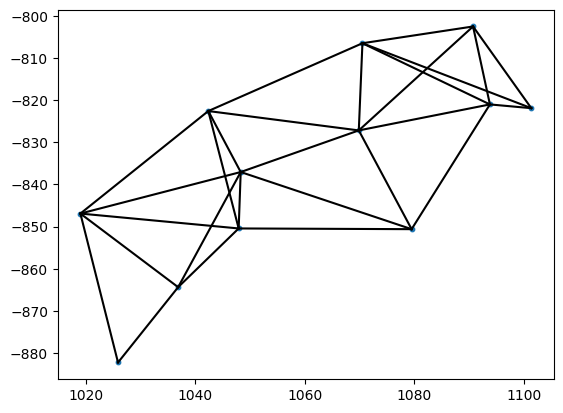

In [28]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['center_x'], nodes['center_y'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['center_x'].values[0], filtered_points[filtered_points['cell'] == node2]['center_x'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['center_y'].values[0], filtered_points[filtered_points['cell'] == node2]['center_y'].values[0]], c='black')

In [30]:
with open(os.path.join(neighborhood_dir, 'sub_graphs_r1_7263.pkl'), 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [31]:
with open(os.path.join(neighborhood_dir, 'sub_graphs_r1_7263_cell_index.pkl'), 'wb') as f:
    pickle.dump(cells_idx, f)

In [2]:
sub_graph_l = pd.read_pickle(r'..\results\stromal_neighborhoods\sub_graphs_r1_7263.pkl')

In [10]:
filtered_points

,cell,volume,center_x,center_y,n_counts,n_genes,leiden,cell_type
0,1381558700001100041,1244.177621,1042.379424,-822.576048,20,19,17,Stromal
1,1381558700001100046,935.224155,1048.295402,-837.055140,116,78,2,Stromal
2,1381558700001100048,2687.832009,1019.025717,-846.911174,300,137,2,Stromal
3,1381558700001100049,834.602354,1047.925600,-850.446140,71,54,17,Stromal
4,1381558700001100051,1201.937941,1036.872597,-864.385508,131,91,17,Stromal
...,...,...,...,...,...,...,...,...
25782,1381558700044100108,2342.231138,1242.486695,-3350.617630,981,206,5,Acini
25783,1381558700044100110,423.353351,1286.325471,-3345.759000,13,9,4,Stromal
25784,1381558700044100111,384.626448,1255.858796,-3355.051188,71,30,4,Stromal
25785,1381558700044100115,220.540095,1249.885004,-3356.811018,32,19,4,Stromal


In [3]:
sub_graph_l[0]

[(np.int64(1381558700001100041), np.int64(1381558700001100048)),
 (np.int64(1381558700001100041), np.int64(1381558700002100128)),
 (np.int64(1381558700001100041), np.int64(1381558700001100049)),
 (np.int64(1381558700001100041), np.int64(1381558700002100143)),
 (np.int64(1381558700001100041), np.int64(1381558700001100046)),
 (np.int64(1381558700001100046), np.int64(1381558700002100156)),
 (np.int64(1381558700001100046), np.int64(1381558700001100048)),
 (np.int64(1381558700001100046), np.int64(1381558700001100051)),
 (np.int64(1381558700001100046), np.int64(1381558700002100143)),
 (np.int64(1381558700001100046), np.int64(1381558700001100049)),
 (np.int64(1381558700001100048), np.int64(1381558700001100055)),
 (np.int64(1381558700001100048), np.int64(1381558700001100049)),
 (np.int64(1381558700001100048), np.int64(1381558700001100051)),
 (np.int64(1381558700001100049), np.int64(1381558700002100156)),
 (np.int64(1381558700001100049), np.int64(1381558700001100051)),
 (np.int64(13815587000011

## R2-7299

In [32]:
filtered_points = pd.read_csv(r'..\results\202602051550_msg2-815IO_VMSC11512_region_R2-7299_annotated_filtered.csv')
unique_edges = pd.read_pickle(r'..\results\stromal_neighborhoods\r2_7299_filterededges.pkl')

In [33]:
cells = filtered_points[filtered_points['cell_type'] == 'Stromal']
cells_idx = cells.index.tolist()

In [34]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.16469907760620117s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

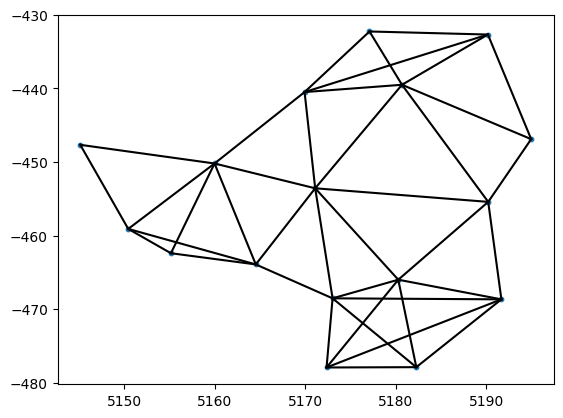

In [35]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['center_x'], nodes['center_y'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['center_x'].values[0], filtered_points[filtered_points['cell'] == node2]['center_x'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['center_y'].values[0], filtered_points[filtered_points['cell'] == node2]['center_y'].values[0]], c='black')

In [36]:
with open(os.path.join(neighborhood_dir, 'sub_graphs_r2_7299.pkl'), 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [37]:
with open(os.path.join(neighborhood_dir, 'sub_graphs_r2_7299_cell_index.pkl'), 'wb') as f:
    pickle.dump(cells_idx, f)

## R4-7219

In [38]:
filtered_points = pd.read_csv(r'..\results\202602051550_msg2-815IO_VMSC11512_region_R4-7219_annotated_filtered.csv')
unique_edges = pd.read_pickle(r'..\results\stromal_neighborhoods\r4_7219_filterededges.pkl')

In [39]:
cells = filtered_points[filtered_points['cell_type'] == 'Stromal']
cells_idx = cells.index.tolist()

In [40]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

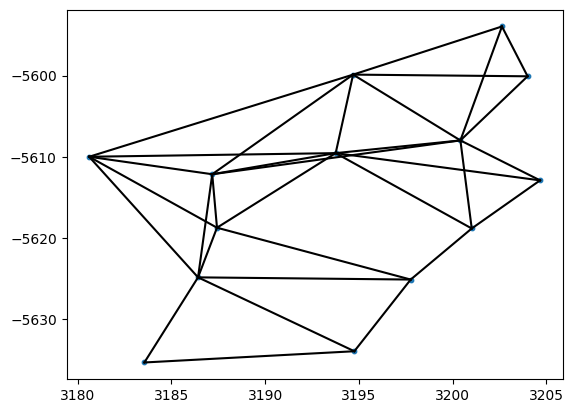

In [41]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['center_x'], nodes['center_y'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['center_x'].values[0], filtered_points[filtered_points['cell'] == node2]['center_x'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['center_y'].values[0], filtered_points[filtered_points['cell'] == node2]['center_y'].values[0]], c='black')

In [42]:
with open(os.path.join(neighborhood_dir, 'sub_graphs_r4_7219.pkl'), 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [43]:
with open(os.path.join(neighborhood_dir, 'sub_graphs_r4_7219_cell_index.pkl'), 'wb') as f:
    pickle.dump(cells_idx, f)

## R5-7223

In [44]:
filtered_points = pd.read_csv(r'..\results\202602051550_msg2-815IO_VMSC11512_region_R5-7223_annotated_filtered.csv')
unique_edges = pd.read_pickle(r'..\results\stromal_neighborhoods\r5_7223_filterededges.pkl')

In [45]:
cells = filtered_points[filtered_points['cell_type'] == 'Stromal']
cells_idx = cells.index.tolist()

In [46]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.19912123680114746s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]

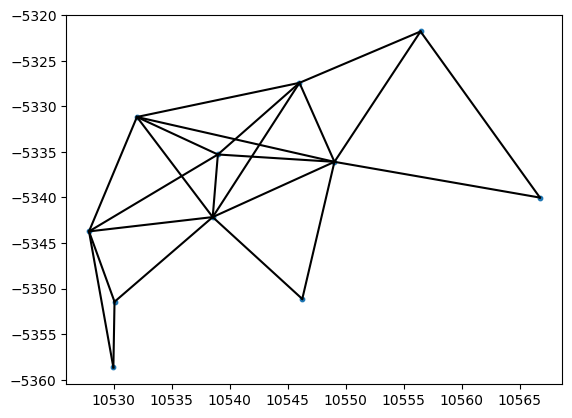

In [47]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['center_x'], nodes['center_y'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['center_x'].values[0], filtered_points[filtered_points['cell'] == node2]['center_x'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['center_y'].values[0], filtered_points[filtered_points['cell'] == node2]['center_y'].values[0]], c='black')

In [48]:
with open(os.path.join(neighborhood_dir, 'sub_graphs_r5_7223.pkl'), 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [49]:
with open(os.path.join(neighborhood_dir, 'sub_graphs_r5_7223_cell_index.pkl'), 'wb') as f:
    pickle.dump(cells_idx, f)

# normalize common genes between merfish and xenium

In [15]:
import scanorama
from tqdm import tqdm
from scipy import io
import gzip

In [16]:
# Load xenium raw expression
in_dir = r'Y:\coskun-lab\Zhou\12_MSG\20240718_xenium\catalyst_release_AC_EU_Jul18'
fn_l = os.listdir(in_dir)
fn_l.sort()

xenium_cells = []
xenium_samples = []
xenium_data = []
xenium_genes = []
for fn in tqdm(fn_l):
    if 'HnE' in fn:
        continue
    if os.path.isdir(os.path.join(in_dir,fn,'cell_feature_matrix')) == False:
        continue
    else:
        with gzip.open(os.path.join(in_dir,fn,'cell_feature_matrix','matrix.mtx.gz'), 'rb') as f:
            mtx = io.mmread(f)
        mtx = mtx.todense().T
        mtx = mtx[:,:480]
        features = pd.read_csv(os.path.join(in_dir,fn,'cell_feature_matrix','features.tsv.gz'), sep='\t', header=None)
        barcodes = pd.read_csv(os.path.join(in_dir,fn,'cell_feature_matrix','barcodes.tsv.gz'), sep='\t', header=None)

        temp = fn.split('_')
        sample = temp[1] + '_' + temp[2]
        xenium_data.append(mtx)
        xenium_cells.append((sample + '_' + barcodes[0]).tolist())
        xenium_genes.append(features[1].tolist()[:480])
        
        xenium_samples.append([sample] * mtx.shape[0])

  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:01<00:00,  9.86it/s]


In [17]:
# import merfish raw expression
in_dir = r'..'
fn_l = os.listdir(in_dir)
fn_l.sort()

fn_l = ['region_R1-7263', 'region_R2-7299', 'region_R4-7219', 'region_R5-7223']

merfish_data = []
merfish_cells = []
merfish_samples = []
merfish_genes = []
for fn in tqdm(fn_l):
    if os.path.isdir(os.path.join(in_dir, fn)) == False:
        continue
    else:
        df = pd.read_csv(os.path.join(in_dir, fn, 'cell_by_gene.csv'))
        temp = fn.split('_')
        sample = temp[1]
        merfish_data.append(df.values[:,1:816])
        merfish_cells.append((sample+df['cell'].astype('str')))
        merfish_samples.append(fn)
        merfish_genes.append(df.columns.tolist()[1:816])

100%|██████████| 4/4 [00:05<00:00,  1.44s/it]


In [88]:
for i in range(len(xenium_data)):
    xenium_data[i] = np.asarray(xenium_data[i])

In [89]:
for i in range(len(merfish_data)):
    merfish_data[i] = merfish_data[i].astype(np.float32)
for i in range(len(xenium_data)):
    xenium_data[i] = xenium_data[i].astype(np.float32)

In [9]:
for item in merfish_data:
    print(type(item))
for item in xenium_data:
    print(type(item))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.matrix'>
<class 'numpy.matrix'>
<class 'numpy.matrix'>
<class 'numpy.matrix'>
<class 'numpy.matrix'>
<class 'numpy.matrix'>
<class 'numpy.matrix'>
<class 'numpy.matrix'>


In [10]:
for item in merfish_data:
    print(item.dtype)
for item in xenium_data:
    print(item.dtype)

int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64


In [11]:
for item in merfish_genes:
    print(type(item))
for item in xenium_genes:
    print(type(item))

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


In [13]:
corrected, genes = scanorama.correct(merfish_data+xenium_data, merfish_genes+xenium_genes, batch_size=2000)

Found 218 genes among all datasets
[[0.         0.49582003 0.46606615 0.29549322 0.0285123  0.01935975
  0.04647363 0.0371257  0.01564561 0.01212048 0.04510564 0.03989968]
 [0.         0.         0.35119341 0.48946658 0.04120487 0.02795184
  0.06385975 0.05537562 0.02068097 0.01727168 0.06699289 0.05847356]
 [0.         0.         0.         0.33044335 0.04437802 0.02254673
  0.05494722 0.0470373  0.01606522 0.01545361 0.04774103 0.04287122]
 [0.         0.         0.         0.         0.04598758 0.0284926
  0.1382548  0.11360836 0.01942213 0.01890794 0.09406725 0.08447274]
 [0.         0.         0.         0.         0.         0.52384456
  0.24180271 0.19071051 0.26909243 0.25719653 0.27716716 0.23885951]
 [0.         0.         0.         0.         0.         0.
  0.25001189 0.20306331 0.31309196 0.29537604 0.29753128 0.26152309]
 [0.         0.         0.         0.         0.         0.
  0.         0.58878282 0.23468409 0.21489607 0.36035031 0.31523776]
 [0.         0.        

In [14]:
out_dir = r'..\results\dann\common_genes'
os.makedirs(out_dir, exist_ok=True)

In [15]:
merfish_corrected = corrected[:len(merfish_data)]
xenium_corrected = corrected[len(merfish_data):]

In [33]:
for item in xenium_corrected:
    print(type(item))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
for i, sample in tqdm(enumerate(xenium_samples)):
    sample = sample[0]
    xenium_corrected[i] = xenium_corrected[i].toarray()
    df = pd.DataFrame(xenium_corrected[i], columns=genes, index=xenium_cells[i])
    df.index = df.index.str.split('_').str[-1].tolist()
    df.to_csv(os.path.join(out_dir, f'{sample}_corrected.csv'))

1it [09:09, 549.70s/it]

In [ ]:
for i, sample in enumerate(merfish_samples):
    merfish_corrected[i] = merfish_corrected[i].toarray()
    df = pd.DataFrame(merfish_corrected[i], columns=genes, index=merfish_cells[i])
    df.index = df.index.str[2:].tolist()
    df.to_csv(os.path.join(out_dir, f'{sample}_corrected.csv'))